<a href="https://colab.research.google.com/github/dieguito1331/cienciaDatos/blob/05 - Series de Tiempo (SARIMAX).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 ¿Qué es SARIMAX? (Explicación para no técnicos)

**SARIMAX** es un modelo estadístico para hacer **pronósticos de series de tiempo**, ideal cuando los datos presentan:

- Tendencias (crecen o bajan en el tiempo)  
- Estacionalidad (patrones que se repiten)  
- Ciclos  
- Variabilidad aleatoria  
- Influencia de factores externos (precio, marketing, clima, etc.)

Es una evolución más completa de ARIMA, pensada para datos reales de negocio.

---

# ⭐ ¿Por qué es útil SARIMAX?

SARIMAX permite modelar simultáneamente:

### **1) Patrones del pasado**
Cómo los valores previos influyen en los actuales.

### **2) Estacionalidad**
Repeticiones como:
- mayor demanda en ciertos días,
- picos en meses específicos,
- ciclos semanales o anuales.

### **3) Factores externos (la “X”)**
Podés agregar variables adicionales que afectan el resultado:
- presupuesto de marketing  
- precios del producto  
- clima  
- feriados  
- días laborales  
- temperatura  
- tráfico del sitio  

Esta es la parte que hace a SARIMAX muy poderoso para problemas reales.

---

# 📦 ¿Qué significa SARIMAX?

- **S** → *Seasonal*: captura estacionalidad  
- **AR** → *AutoRegressive*: depende de valores pasados  
- **I** → *Integrated*: diferencia la serie para estabilizarla  
- **MA** → *Moving Average*: usa errores pasados para corregir predicciones  
- **X** → *Exogenous*: incluye variables externas que influyen en la serie  

SARIMAX combina estas piezas para modelar fenómenos complejos de negocio.

---

# 📊 ¿Cómo pensarlo de forma intuitiva?

Imaginemos pronosticar ventas semanales.

SARIMAX considera:

1. **Qué pasó en semanas anteriores** (AR)  
2. **Cómo evoluciona la tendencia general** (I)  
3. **Los errores recientes del modelo** (MA)  
4. **Patrones que se repiten cada mes o estación** (S)  
5. **Factores externos** como precio o marketing (X)  

Es como un rompecabezas donde cada componente aporta una parte del patrón total.

---

# 🎯 ¿Cuándo conviene usar SARIMAX?

- Cuando hay **estacionalidad** clara  
- Cuando querés incluir **variables del negocio**  
- Cuando buscás **explicabilidad**  
- Cuando necesitás un modelo **estable y robusto**  
- Cuando tenés varios productos (muchos SKUs)  
- Cuando Prophet no está disponible en el entorno  

Aplicaciones ideales:

- Forecast de ventas  
- Supply chain e inventarios  
- Demanda por SKU  
- Default y cobranzas con fecha  
- Leads o tráfico web  
- Tickets de soporte  

---

# 🧩 Ejemplo práctico (explicado simple)

Queremos predecir ventas semanales de un producto.

SARIMAX:

1. Mira ventas pasadas  
2. Detecta estacionalidad (semanal, mensual, anual)  
3. Ajusta errores previos  
4. Incorpora variables como marketing o precios  
5. Produce un pronóstico con bandas de confianza  

---

# 🚦 Ventajas de SARIMAX

- Excelente para series con estacionalidad  
- Muy explicable (puede desarmarse en componentes)  
- Funciona bien con **muchos SKUs**  
- Estable y confiable para operaciones  
- No requiere millones de datos  
- Permite agregar variables del negocio  

---

# ⚠️ Limitaciones

- No capta relaciones muy complejas como un modelo de Deep Learning  
- Requiere cierta calibración de parámetros  
- No es ideal si la serie cambia abruptamente todo el tiempo  
- Necesita datos limpios y granulado consistente  

---

# 🏁 Conclusión

SARIMAX es un modelo **clásico, robusto y altamente confiable**, ideal para empresas con estacionalidad y series que dependen de variables externas.

Es muy recomendado para áreas como:

✔️ Ventas  
✔️ Supply chain  
✔️ Finanzas  
✔️ Marketing  
✔️ Operaciones  
✔️ Cobranzas  

Su combinación de explicabilidad + estabilidad lo hace perfecto para pronosticar múltiples productos o SKU en entornos reales.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Fechas
dates = pd.date_range("2021-01-01", "2022-12-31", freq="D")
n = len(dates)

# Lista de SKUs
skus = ["SKU_A", "SKU_B", "SKU_C"]

data = []

for sku in skus:
    # Tendencias distintas por SKU
    trend = np.linspace(
        50 if sku=="SKU_A" else 30 if sku=="SKU_B" else 70,
        100 if sku=="SKU_A" else 60 if sku=="SKU_B" else 120,
        n
    )

    # Estacionalidad semanal
    seasonal = 10 * np.sin(2 * np.pi * np.arange(n) / 7)

    # Estacionalidad anual
    seasonal_year = 20 * np.sin(2 * np.pi * np.arange(n) / 365)

    # Ruido
    noise = np.random.normal(0, 8, n)

    sales = trend + seasonal + seasonal_year + noise
    sales = np.maximum(sales, 0)  # no negativas

    for d, s in zip(dates, sales):
        data.append([sku, d, s])

df = pd.DataFrame(data, columns=["sku", "fecha", "ventas"])
df.head()

,sku,fecha,ventas
0,SKU_A,2021-01-01,53.973713
1,SKU_A,2021-01-02,57.125055
2,SKU_A,2021-01-03,65.756394
3,SKU_A,2021-01-04,67.761231
4,SKU_A,2021-01-05,45.438333


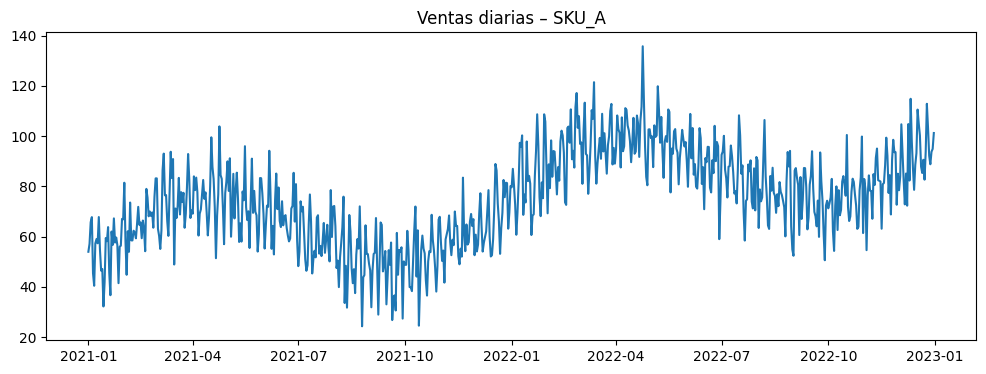

In [3]:
sku = "SKU_A"
df_sku = df[df["sku"] == sku].set_index("fecha")

plt.figure(figsize=(12,4))
plt.plot(df_sku["ventas"], label=sku)
plt.title(f"Ventas diarias – {sku}")
plt.show()

# 📉 Forecasting con ARIMA / SARIMAX

Los modelos **ARIMA** (AutoRegressive Integrated Moving Average) y **SARIMAX**
(SARIMA con regresores externos) son métodos clásicos de forecasting basados
en teoría estadística.

La idea central es modelar una serie estacionaria mediante la combinación de:

- **AR(p)**: dependencia lineal con valores pasados.
- **I(d)**: diferenciación para lograr estacionariedad.
- **MA(q)**: dependencia con errores pasados.

Para series con estacionalidad se utiliza **SARIMA**, agregando un componente estacional:

\[
(p, d, q) \times (P, D, Q)_s
\]

donde `s` es el periodo estacional (por ejemplo, 7 días en estacionalidad semanal).

### Ventajas de ARIMA:

- Muy útil para series bien comportadas.
- Permite modelar relaciones lineales fuertes.
- Con SARIMAX se pueden incorporar regresores externos (clima, marketing, precio).
- Ofrece interpretabilidad estadística a través de los coeficientes del modelo.

### Desventajas:

- Requiere estacionariedad o transformaciones para alcanzarla.
- No maneja fácilmente múltiples estacionalidades complejas.
- Su tuning puede ser difícil sin búsqueda automatizada.

### Flujo de trabajo:

1. Configurar la serie temporal con índice de fecha.
2. Evaluar estacionariedad y estacionalidad.
3. Seleccionar órdenes `(p, d, q)` y `(P, D, Q, s)`.
4. Entrenar el modelo y revisar el resumen estadístico.
5. Realizar predicciones sobre el horizonte de test.
6. Comparar métricas como MAE y RMSE.

ARIMA sigue siendo uno de los modelos más utilizados en planificación de demanda,
particularmente cuando el histórico es consistente y tiene un patrón estable.

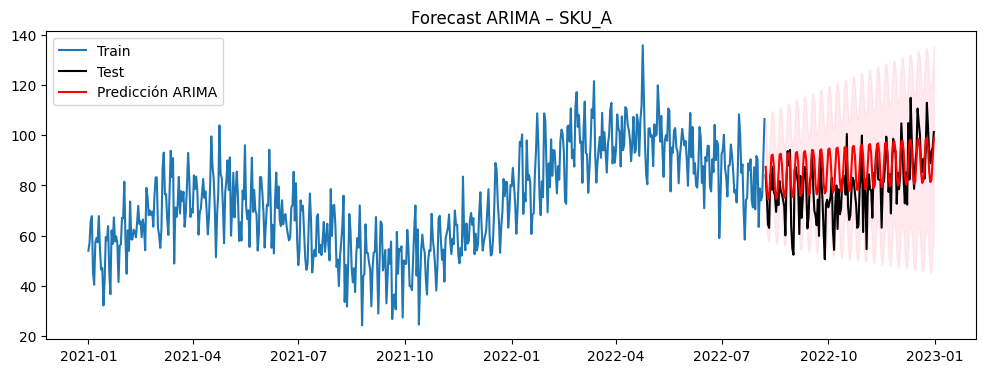

MAE: 9.498322081197339
RMSE: 11.638056550799918


In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Serie con frecuencia explícita
serie = df_sku["ventas"].asfreq("D")

# Train / test
split = int(len(serie)*0.8)
train_arima = serie.iloc[:split]
test_arima  = serie.iloc[split:]

# Modelo
model = SARIMAX(
    train_arima,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),  # estacionalidad semanal
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit()

# Forecast
pred = result.get_forecast(steps=len(test_arima))
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()

# Visualización
plt.figure(figsize=(12,4))
plt.plot(train_arima, label="Train")
plt.plot(test_arima, label="Test", color="black")
plt.plot(pred_mean, label="Predicción ARIMA", color="red")
plt.fill_between(pred_ci.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], color="pink", alpha=0.3)
plt.title(f"Forecast ARIMA – {sku}")
plt.legend()
plt.show()

# Métricas
mae = mean_absolute_error(test_arima, pred_mean)
rmse = np.sqrt(mean_squared_error(test_arima, pred_mean))

print("MAE:", mae)
print("RMSE:", rmse)